In [1]:
import geopandas as gpd

gpkg_path = '../data/floresta_plantada_ief_2025.gpkg'
gdf_silvi = gpd.read_file(gpkg_path)

In [2]:
print("Dataset Info:")
print(gdf_silvi.info())
print("\nHead:")
print(gdf_silvi.head())

print(f"\nCRS: {gdf_silvi.crs}")

Dataset Info:
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 171302 entries, 0 to 171301
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   _uid_          171302 non-null  int64         
 1   id             171302 non-null  int32         
 2   codigocar      171302 non-null  str           
 3   codigoplan     171302 non-null  str           
 4   situacaopl     171302 non-null  str           
 5   areahaplan     171302 non-null  str           
 6   perccolhid     171302 non-null  str           
 7   statusarea     171209 non-null  str           
 8   tipo           171302 non-null  str           
 9   codigoarea     171302 non-null  str           
 10  nomecomum      171302 non-null  str           
 11  nomecienti     171302 non-null  str           
 12  essencia       171302 non-null  str           
 13  datacria       171302 non-null  datetime64[ms]
 14  identificador  171302 non-null

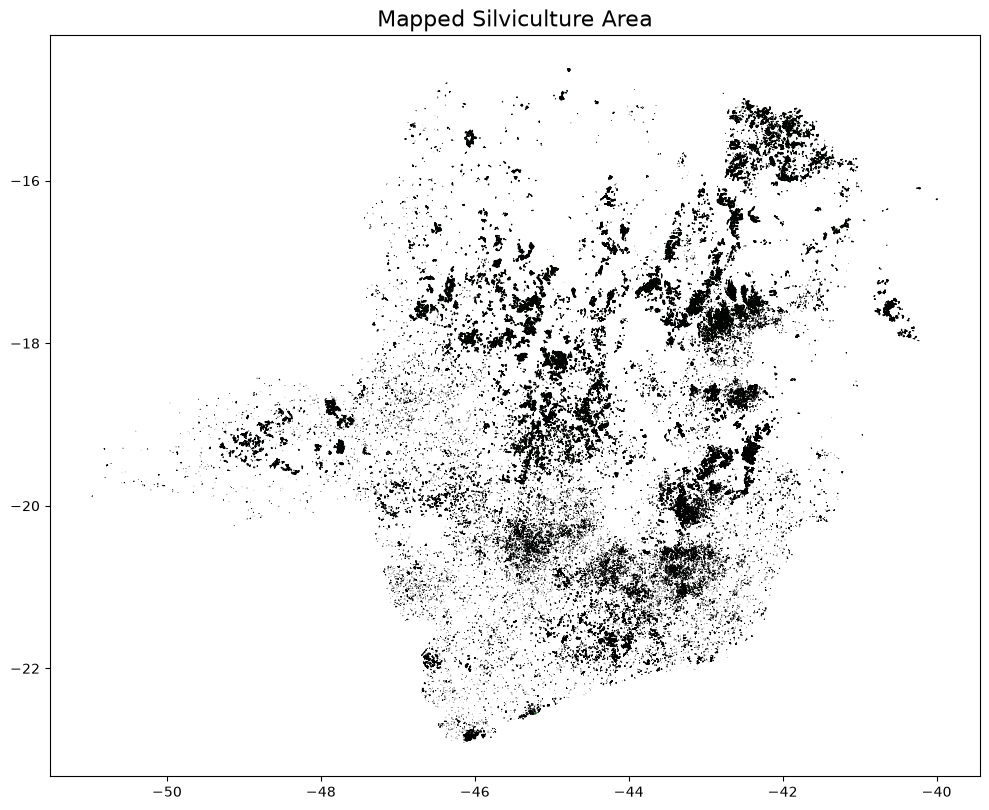

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))
gdf_silvi.plot(ax=ax, color='forestgreen', edgecolor='black', linewidth=0.5)
ax.set_title('Mapped Silviculture Area', fontsize=16)
plt.show()

In [4]:
shp = '../data/MG_Municipios_2025/MG_Municipios_2025.shp'

gdf_silv = gpd.read_file(gpkg_path)
gdf_mun = gpd.read_file(shp)

# EPSG:31983 - SIRGAS 2000 / UTM zone 23S
gdf_silv = gdf_silv.to_crs(epsg=31983)
gdf_mun = gdf_mun.to_crs(epsg=31983)

In [5]:
# Idea is a proportion between territory / silviculture area
# Top 10 cities with the biggest proportion

import pandas as pd

# Total area
# 1 hectare = 10.000 metros quadrados
gdf_mun['area_total_ha'] = gdf_mun.geometry.area / 10000

silv_mun = gpd.overlay(gdf_silv, gdf_mun, how='intersection')

# Silviculture area
silv_mun['area_silv_ha'] = silv_mun.geometry.area / 10000

# Group by city
area_por_mun = silv_mun.groupby('NM_MUN')['area_silv_ha'].sum().reset_index()

# Proportion
ranking = pd.merge(gdf_mun[['NM_MUN', 'area_total_ha']], area_por_mun, on='NM_MUN', how='left')

# No silviculture
ranking['area_silv_ha'] = ranking['area_silv_ha'].fillna(0)

ranking['proporcao_%'] = (ranking['area_silv_ha'] / ranking['area_total_ha']) * 100

top_10 = ranking.sort_values(by='proporcao_%', ascending=False).head(10)

print("\nCities with largest silviculture area:")
print(top_10[['NM_MUN', 'area_total_ha', 'area_silv_ha', 'proporcao_%']])


Cities with largest silviculture area:
                  NM_MUN  area_total_ha  area_silv_ha  proporcao_%
792           Taiobeiras  122207.609652  33629.537804    27.518366
96    Santana do Paraíso   27581.727858   7167.439254    25.986187
440         Belo Oriente   33523.640033   8408.478559    25.082236
564            Carbonita  145647.350772  35746.627663    24.543274
470  São João do Paraíso  192906.614052  44185.260663    22.905000
356                Ipaba   11336.882135   2453.891408    21.645205
706          Josenópolis   54187.584588  11345.529949    20.937508
452            Veredinha   63209.879866  12602.206430    19.937083
107          Minas Novas  181428.513699  35104.879307    19.349152
213         Itamarandiba  273691.439008  52205.081300    19.074430
